<a href="https://colab.research.google.com/github/alextyner-tailwater/Tailwater/blob/main/Tutorials/Compute_Z2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load Packages
!pip install tailwater
!pip install pybinding-dev
!pip install seekpath
!pip install mp_api
!pip install z2pack

In [9]:
#Define API Keys:
#Materials Project API Key
API_KEY = #Your Materials Project API Key
#Tailwater User + Password
TW_USER= # Your Tailwater Username
TW_PASS= #Your Tailwater Password

In [ ]:
import os
from mp_api.client import MPRester
mp_id='mp-104' #Materials Project ID for Sb
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

In [30]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)
import pybinding as pb
import matplotlib.pyplot as plt

In [31]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat")

In [32]:
# Load the HDF5 the API produced — returns a tbmodels.Model with .to_pb()
model = tb_model.load("outputs/wannier90_hr.hdf5")
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)

[bands] path total length = 4.1096  -> N_path = 206 samples (spacing = 0.02)


Band structure: 100%|██████████| 206/206 [00:00<00:00, 783.40it/s]


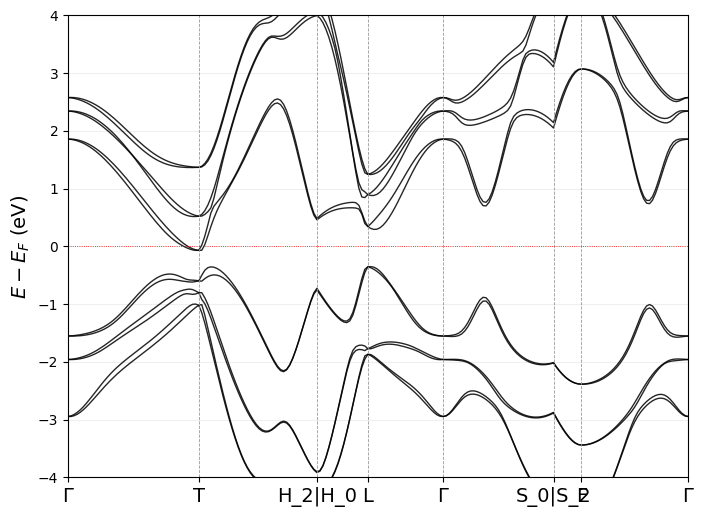

In [41]:
#Plot band structure using SeeKPath
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-4, 4))
fig

Now that we have the model we can use Z2Pack to compute Wannier Center Charges and extract the Z2 index

In [ ]:
import z2pack
settings = {
    "num_lines": 81,
    "pos_tol": 1e-2,
    "gap_tol": 2e-2,
    "move_tol": 0.3,
    "iterator": range(101, 121, 2),

    "min_neighbour_dist": 1e-4,
}
occ_bands= np.sum(np.heaviside(-model.eigenval([0,0,0]),0))
tb_system = z2pack.tb.System(model, bands= int(occ_bands-2))

result_0 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [0, s / 2, t],
    **settings
)
result_1 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [0.5, s / 2, t],
    **settings
)

result_2 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [s/2, 0, t],
    **settings
)
result_3 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [s/2, .5, t],
    **settings
)

result_4 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [t, s / 2, 0],
    **settings
)
result_5 = z2pack.surface.run(
    system=tb_system,
    surface=lambda s, t: [t, s / 2, 0.5],
    **settings
)


Now compute topological invariants

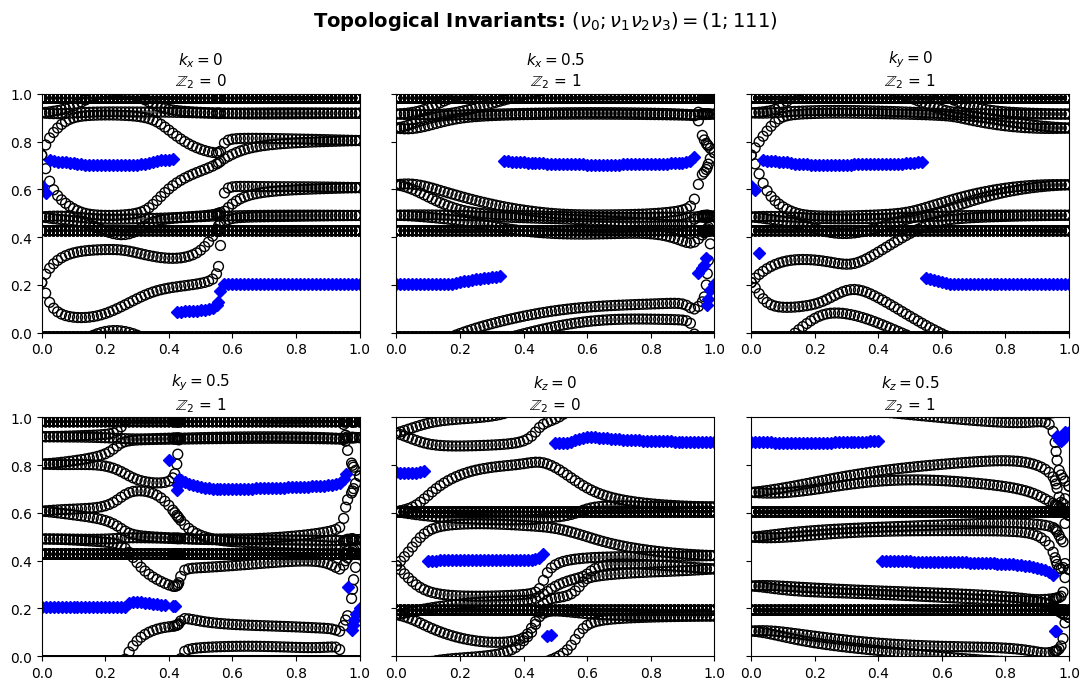

In [66]:

import matplotlib.pyplot as plt
import z2pack



# 2. Extract the Z2 invariants from each tracked plane manifold
x0 = z2pack.invariant.z2(result_0)
x1 = z2pack.invariant.z2(result_1)
y0 = z2pack.invariant.z2(result_2)
y1 = z2pack.invariant.z2(result_3)
z0 = z2pack.invariant.z2(result_4)
z1 = z2pack.invariant.z2(result_5)

# 3. Compute topological indices using modulo 2 arithmetic
nu_0 = (x0 + x1) % 2  # Strong index
nu_1 = x1 % 2         # Weak indices
nu_2 = y1 % 2
nu_3 = z1 % 2

# 4. Initialize the grid plotting environment
fig, ax = plt.subplots(2, 3, sharey=True, figsize=(11, 7))

# Reshape axis array into a flat list for seamless iteration
axes_flat = ax.flatten()
results = [result_0, result_1, result_2, result_3, result_4, result_5]
plane_labels = [
    r"$k_x = 0$", r"$k_x = 0.5$",
    r"$k_y = 0$", r"$k_y = 0.5$",
    r"$k_z = 0$", r"$k_z = 0.5$"
]
invariants = [x0, x1, y0, y1, z0, z1]

# 5. Populate subplots with WCC evolution trajectories
for i, axis in enumerate(axes_flat):
    z2pack.plot.wcc(results[i], axis=axis)
    axis.set_title(f"{plane_labels[i]}\n$\\mathbb{{Z}}_2$ = {invariants[i]}", fontsize=11)

    # Optional clean-up: remove redundant inner labels
    if i < 3:
        axis.set_xlabel("")
    if i % 3 != 0:
        axis.set_ylabel("")

# 6. Global figure formatting
main_title = f"Topological Invariants: $(\\nu_0; \\nu_1\\nu_2\\nu_3) = ({nu_0}; {nu_1}{nu_2}{nu_3})$"
fig.suptitle(main_title, fontsize=14, fontweight="bold", y=0.98)

plt.tight_layout()
plt.show()

Now that we see this is a TI lets take a look at the surface states. This can be done rapidly using KPM + Tailwater

In [ ]:
skpm = SurfaceSpectralDensity(
        model, surface=np.eye(3), LZ=5,
        energies=(-1.0, 1.0),
        k_path=[[0, 0.5, 0], [0, 0, 0], [0.333, 0.333, 0]],
        k_labels=["M", r"$\Gamma$", "K"],
        N_path=101, NC=2 ** 12, NV=4, device="cpu",
    ).run()


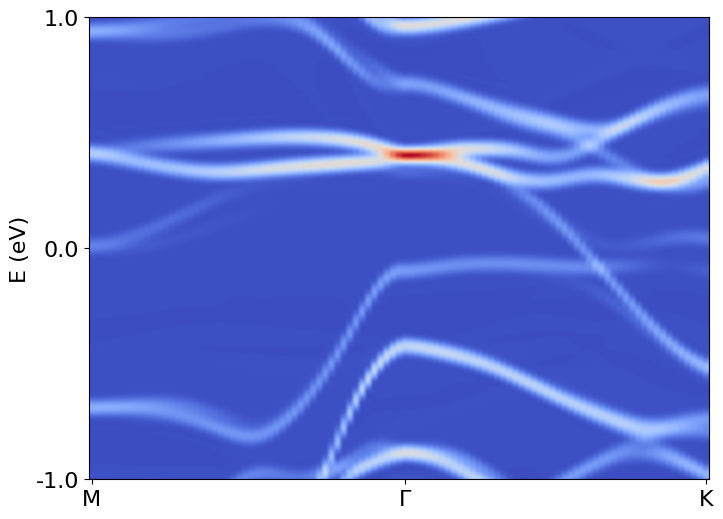

In [68]:
skpm.figure_top

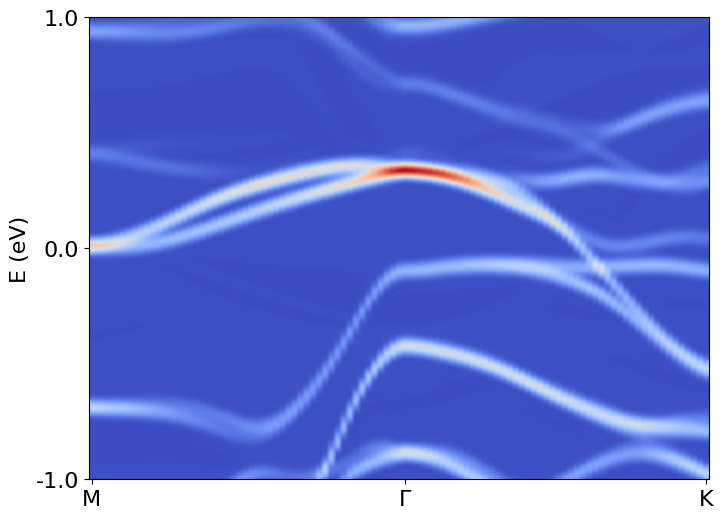

In [69]:
skpm.figure_bottom